In [36]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # Use GPU if available
device

device(type='cuda', index=0)

In [37]:
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
#print total number of words and characters in the vocabulary
print(f'{len(words)} words, {len(chars)} unique characters')

32033 words, 26 unique characters


In [39]:
# Build the dataset
block_size = 3  # context length: how many characters used to predict the next? (1 before)
X, Y = [], []   # features (input) and labels (output)

# Just show the first three words as example
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        
        X.append(context)
        Y.append(ix)
        
        # Showing what input and expected output now look like
        context = context[1:] + [ix] # crop and append, like a rolling window; NEAT!

# These DO NOT carry characters, but their respective index numbers
X = torch.tensor(X, device=device)
Y = torch.tensor(Y, device=device)

print('Input:', X.shape, X.dtype, X[0])
print('Output:', Y.shape, Y.dtype, Y[0]) 

Input: torch.Size([228146, 3]) torch.int64 tensor([0, 0, 0], device='cuda:0')
Output: torch.Size([228146]) torch.int64 tensor(5, device='cuda:0')


In [40]:
g = torch.Generator(device=device).manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g, device=device)     #  27 characters, 2 dimensions each
W1 = torch.randn((6,100), generator=g, device=device)   #   3 characters times 2 embedding values as inputs to 100 neurons
b1 = torch.randn((100), generator=g, device=device)     # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g, device=device)  # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g, device=device)      #  27 biases added to the 27 output neurons

parameters = [C, W1, b1, W2, b2] # Cluster all parameters into one structure

print(sum(p.nelement() for p in parameters), 'parameters') # Network stays the same, so same number of parameters

# Allowing for gradient accumulation
for p in parameters:
    p.requires_grad = True

3481 parameters


In [41]:
# For the 32 input dataset, we had used 1000 epochs
# Now, for the much larger dataset, we can reduce this to 10 epochs
lossi = []
stepi = []
i = 0
for _ in range(100):
    ## Forward-Pass
    emb = C[X] # (228146, 3, 2), *ALL AT ONCE*
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (228146, 100)
    logits = h @ W2 + b2 # (228146, 27)

    # Leaving this here for happy memories of low performance:
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    
    loss = F.cross_entropy(logits, Y)
    
    lossi.append(loss.item())
    stepi.append(i)
    print(loss.item())
    i += 1

    ## Backward-Pass
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    # Update
    for p in parameters:
        p.data += -0.1 * p.grad

14.74382209777832
13.678346633911133
12.868627548217773
12.265697479248047
11.80678939819336
11.409015655517578
11.04092788696289
10.693868637084961
10.361305236816406
10.042839050292969
9.73672866821289
9.444010734558105
9.162611961364746
8.895929336547852
8.643705368041992
8.405805587768555
8.182060241699219
7.970251083374023
7.768829345703125
7.577558994293213
7.393733978271484
7.21772575378418
7.048461437225342
6.885107517242432
6.728193283081055
6.576963901519775
6.433106422424316
6.295088768005371
6.164615154266357
6.040782928466797
5.923329830169678
5.811599254608154
5.70367431640625
5.600320816040039
5.499889373779297
5.402886390686035
5.308992862701416
5.2174506187438965
5.1299848556518555
5.045505046844482
4.96370792388916
4.885990619659424
4.811108112335205
4.739749431610107
4.671963214874268
4.606466770172119
4.544840335845947
4.48638391494751
4.430290699005127
4.376835823059082
4.325858116149902
4.276776313781738
4.229525566101074
4.183992862701416
4.139752388000488
4.0976

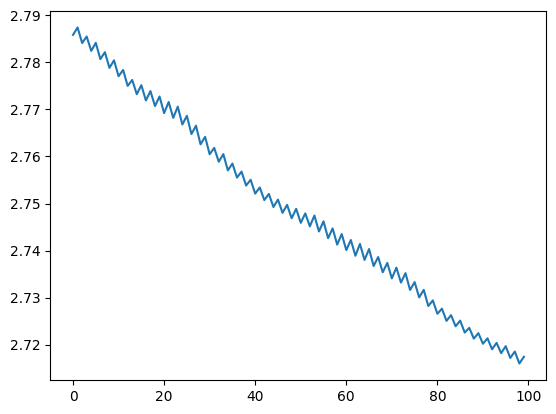

In [28]:
plt.plot(stepi, lossi);

In [35]:
# sample from the model
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        
        if ix == 0:
            break
            
    print(''.join(itos[i] for i in out))

bbkntsn.
ymenmarirenajrnh.
rdr.
leye.
lidzaomurahhecanrh.
aro.
dgeeih.
lsin.
mer.
tarelcohiaasstttatt.
kerhecdynazr.
hraan.
jeilana.
doina.
ari.
imohihekzxlas.
aarsveng.
baan.
jxcezar.
gieirei.
